# Project on Time Series Analysis Project

## **Title:** Time series Analyisi on Reliance Sotck

**Introduction**<br>
The objective of this project is to analyze the statistical properties of the daily returns of Reliance Industries Ltd using time-series techniques



1.   Do stationarty exhibit in reliance return
2.   Is there any serial dependanece on the past return


**Methodology:**


The analysis follows a structured time-series workflow:

1.  Collect historical daily stock prices.
2.  Convert price data into return series.
3.  Test stationarity using: Augmented Dickey–Fuller Test Kwiatkowski–Phillips–Schmidt–Shin Test
4.  Examine serial dependence using: Autocorrelation Function (ACF) Partial,Autocorrelation Function (PACF)



# Data Collection

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import yfinance as yf
import pandas as pd
import  warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [ ]:
ticker_name = "RELIANCE"
data = yf.download(tickers=f"{ticker_name}.NS", start="2013-01-01", end="2025-12-31", progress=False)
#data = yf.download(tickers=f"{ticker_name}", start="2000-01-01", end="2025-12-31", progress=False)

In [ ]:
Closing_price = data["Close"][f'{ticker_name}.NS'].tail(int(len(data)*.5))
#Closing_price = Closing_price.pct_change().dropna()

#Closing_price = data["Close"][f'{ticker_name}']

Closing_price.index = pd.to_datetime(Closing_price.index)

Closing_price.index

DatetimeIndex(['2019-07-09', '2019-07-10', '2019-07-11', '2019-07-12',
               '2019-07-15', '2019-07-16', '2019-07-17', '2019-07-18',
               '2019-07-19', '2019-07-22',
               ...
               '2025-12-16', '2025-12-17', '2025-12-18', '2025-12-19',
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-26',
               '2025-12-29', '2025-12-30'],
              dtype='datetime64[ns]', name='Date', length=1603, freq=None)

# Analysis

## EDA
## Classical Decomposition

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
decompose = seasonal_decompose(Closing_price, model="additive", period=25)

trend = decompose.trend
seasonal = decompose.seasonal
residual = decompose.resid

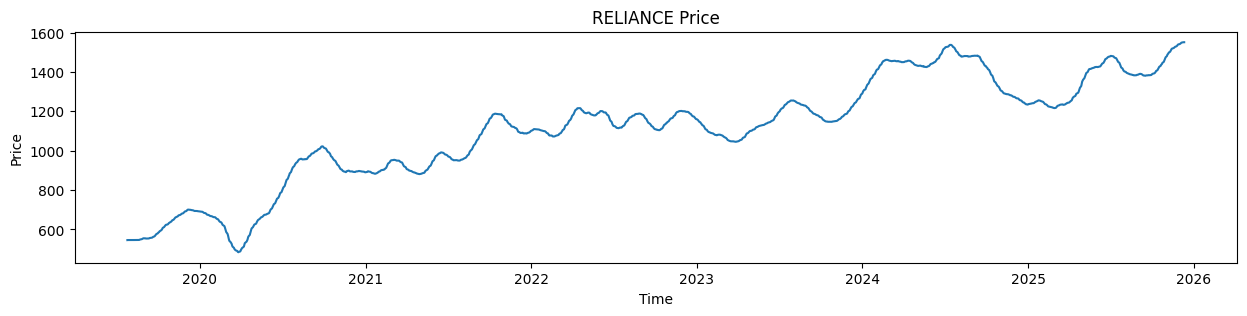

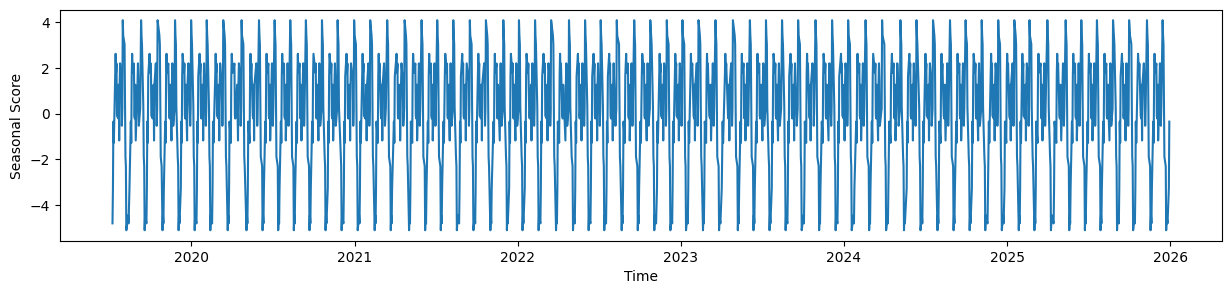

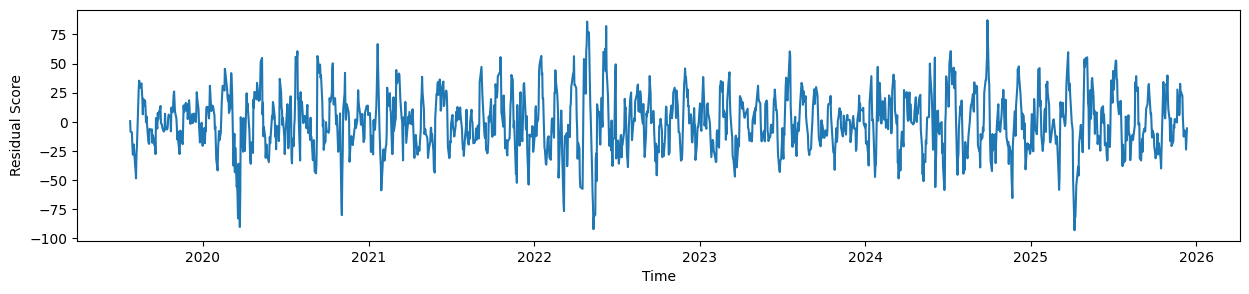

In [ ]:
plt.figure(figsize=(15,3))
plt.plot(trend, label="Trend")
plt.title(f"{ticker_name} Price"  )
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(15,3))
plt.plot(seasonal, label="Seasonal")
plt.xlabel("Time")
plt.ylabel("Seasonal Score")
plt.show()



plt.figure(figsize=(15,3))
plt.plot(residual, label="Seasonal")
plt.xlabel("Time")
plt.ylabel("Residual Score")
plt.show()

## Seasonality Test
### ADF
### KPSS

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np

percentage_change = np.log(Closing_price/Closing_price.shift(1)).dropna()

In [ ]:
def adf_summery(adfuller_stats):
 summary_ =  f"""
 ADF_stat = {round(adfuller_test[0],10)}
 p-value = {round(adfuller_test[1],10)}
 Lags used = {adfuller_test[2]}
 No of observations used = {adfuller_test[3]}
 ------------------------------
 Critical Values

 {pd.Series(adfuller_test[4])}
 ------------------------------
 Hypothesis:
 Ho = There is unit root(Time series is non stationary)
 Ha = There is no unit root(Time series is stationary)
 ------------------------------
 Conclusion:

 {
     'Time Series is stationary'   if adfuller_test[1] <0.05 else 'Time series is not Stationary'
 }"""
 return summary_
def kpss_summary(kpss_test):
  summary_ =  f"""
  KPSS Statistic = {kpss_test[0]}
  p-value = {kpss_test[1]}
  ----------------------
  Critical value:
  {pd.Series(kpss_test[3])}
  ----------------------
  Hypothesis:
  Ho = Time series is stationary
  Ha = Time series is not stationary
  ----------------------
  Conclusion:
  ----------------------
  {'Time series is not stationary' if kpss_test[1]<=0.05 else' Time series is stationary'}
  """
  return summary_

In [ ]:
adfuller_test  = adfuller(percentage_change, maxlag=30)
print(adf_summery(adfuller_stats=adfuller_test))



 ADF_stat = -11.7997595027
 p-value = 0.0
 Lags used = 10
 No of observations used = 1591
 ------------------------------
 Critical Values
 
 1%    -3.434467
5%    -2.863358
10%   -2.567738
dtype: float64
 ------------------------------
 Hypothesis:
 Ho = There is unit root(Time series is non stationary)
 Ha = There is no unit root(Time series is stationary)
 ------------------------------
 Conclusion:
 
 Time Series is stationary


In [ ]:
#kpss
kpss_test = kpss(percentage_change, regression="c", nlags=30)
print(kpss_summary(kpss_test))


  KPSS Statistic = 0.07242537820303438
  p-value = 0.1
  ----------------------
  Critical value:
  10%     0.347
5%      0.463
2.5%    0.574
1%      0.739
dtype: float64
  ----------------------
  Hypothesis:
  Ho = Time series is stationary
  Ha = Time series is not stationary
  ----------------------
  Conclusion:
  ----------------------
   Time series is stationary
  


Based on ADF and KPSS it is comcluded that Time series is stationary

## ACF and PACF Plot

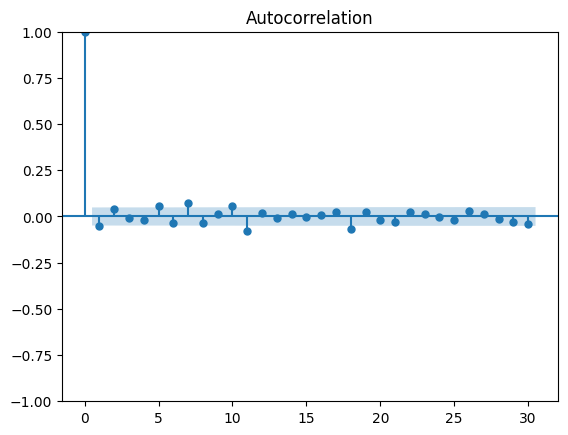

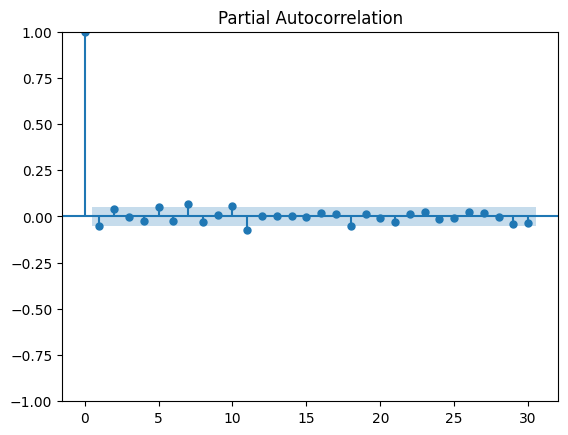

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
acf = plot_acf(percentage_change, lags=30)
pacf = plot_pacf(percentage_change, lags=30)

There are no such autocorrelation

# Conclussion
The results of the stationarity tests indicate that the return series is stationary. The Augmented Dickey–Fuller test rejects the null hypothesis of a unit root, while the KPSS test fails to reject the null hypothesis of stationarity. This provides strong statistical evidence that the return series is stationary.

Further analysis using ACF and PACF plots shows that the autocorrelation coefficients are not statistically significant at different lags. This indicates that the return series does not exhibit significant dependence on its past values